### Step1: Import Libraries

In [1]:
import os
from openai import OpenAI
from dotenv import load_dotenv
import gradio as gr
from openai import OpenAI
import json
from pprint import pprint
 
load_dotenv()

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
if OPENAI_API_KEY is None:
    raise Exception("API Key is missing!")
else:
    print("Key is: " + OPENAI_API_KEY[:8])

client = OpenAI(api_key=OPENAI_API_KEY)


c:\DEV\skool\ai-engineering\ai_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Key is: sk-proj-


### Step 2: RAG Preparation

In [2]:
system_message = """ 

Important: do not make something up. If you don't know the answer, just say I donot know
The only factual information available to you is what is in this system message.
You can't get any more facts about Si Lam from the internet or make something up.
Here is the ONLY factual information about Si Lam

If the question is asked that is not answerable, say I don't know.
"""


document = """

My name is Si Lam,

I have Microsoft Azure Certified: AI-102, AZ-420, DP-900,DP-700,DP-600,D-100,AZ-400,AZ-104,AZ-204

also I have Amazon Web Service AWS Certified: Administrator and Developer;, 



I am Senior Software Engineer at Red Wing Shoes, working on Front End Javascript, Blazor, and
back end API

You can follow me at my personal website: http://www.serverlessdeveloper.com

I am based in SMinnesota, United States

My Contact info: silam@hotmail.com 

I got my master degree in Software Engineering at University of St. Thomas in 2015
I got my BS at Augsburg College

Here is the list of AWS Certification 

AWS Certified Solution Architect - Associate 
AWS Certified Developer 

Here is the list of Microsoft Azure Certification:

Microsoft Certified Azure AI Engineer Associate (AI-102)
Microsoft Certified Azure Administrator Associate (AZ-104)
Microsoft Certified Developer (AZ-204)
Microsoft Certified DevOps Certified Engineer Expert (AZ-400) 
Microsoft Certified Data Scientist Associate (DP-100)
Microsoft Certified Azure Cosmos DB Developer Specialty (AZ-420)
Microsoft Certified Azure Data Fundamentals (DP-900)

My portfolio is at http://serverlessdeveloper.com/
ReactJS, Angular, NodeJS, .NET core, Microsoft Azure Certified, AWS certified solution architect, Developer Certified, API Gateway, AWS Lambda functions, Azure DynamoDb, AWS CosmoDB

Contact me at si.lam@serverlessdeveloper.com

Skills with Microsoft Certified: Fabric Analytics Engineer Associate
1-Maintain a data analytics solution
2-Prepare data
3-Implement and manage semantic models


Skills measured:
Plan and manage an Azure AI solution
Implement decision support solutions
Implement computer vision solutions
Implement natural language processing solutions
Implement knowledge mining and document intelligence solutions
Implement generative AI solutions




Skills at Microsoft Certified: Azure Cosmos DB Developer Specialty

Skills measured
Design and implement data models
Design and implement data distribution
Integrate an Azure Cosmos DB solution
Optimize an Azure Cosmos DB solution
Maintain an Azure Cosmos DB solution


Azure Data Fundamentals Certification


Skills at AWS Developer Certificate

Master Advanced AWS Services: Deepen your knowledge of AWS by exploring advanced services such as AWS Lambda, Amazon S3, Amazon EC2, and AWS Elastic Beanstalk. Understanding the nuances of these services can help you design and deploy scalable, high-performance applications.
Gain Proficiency in Infrastructure as Code (IaC): Tools like AWS CloudFormation and Terraform are becoming industry standards. Learning to automate cloud infrastructure provisioning through IaC can significantly improve efficiency and accuracy in deployments.
Stay Current with AWS Certifications: Regularly update your certifications, such as the AWS Certified Developer – Associate or AWS Certified DevOps Engineer – Professional, to validate your skills and stay aligned with the latest AWS features and best practices.
Develop Expertise in Serverless Architectures: Embrace the serverless paradigm by learning how to build and manage applications with AWS serverless technologies, which can lead to cost savings and operational simplicity.
Participate in AWS Hackathons and Challenges: Engage in competitive coding and problem-solving events to push your limits, innovate with AWS technologies, and learn from your peers.
Contribute to Open Source Projects: Get involved in open source projects that use AWS technologies to gain practical experience, collaborate with other developers, and contribute to the community.
Enhance Data Skills with AWS Analytics Services: Develop your ability to work with data by using AWS analytics services like Amazon Redshift, AWS Glue, and Amazon Athena to process, analyze, and visualize data at scale.
Focus on Security Best Practices: Prioritize learning about AWS security services such as AWS Identity and Access Management (IAM), Amazon Cognito, and AWS Key Management Service (KMS) to ensure the applications you develop are secure and compliant.
Adopt a DevOps Culture: Integrate DevOps practices into your workflow by using AWS tools like AWS CodeBuild, AWS CodeDeploy, and AWS CodePipeline to automate software delivery processes and foster a culture of continuous integration and continuous delivery (CI/CD).
Engage with the AWS Community: Join AWS user groups, forums, and social media communities to exchange knowledge, stay informed about new developments, and build a professional network within the AWS ecosystem.

Show all featured items


Azure Certified: AI-102, AZ-420, DP-900,DP-700,DP-600,D-100,AZ-400,AZ-104,AZ-204
AWS Certified: Admin& Developer;, ReactJS, FastAPI, Serverless AppSenior Software Engineer at Red Wing Shoes.serverlessdeveloper.com

 In 2000, I Just graduated from Ausbug College

Cooking: Enjoy cooking food every day

I love watching soccer and play soccer. I love to watch UEFA Champion Leaguage and FIFA World Cup. 
Since Messi plays for Inter Miami, I watch and follow Messi's team every game.


"""

In [ ]:
#Split text into chunks
def split_text_into_chunks(text: str, chunk_size: int = 500, overlap: int = 50) -> list[str]:
    
    BOUNDARIES = ["\n\n","\n",". ", "? ", "! "," "]


    def find_natural_boundary(start: int, end: int) -> int:
        midpoint = start + (chunk_size // 2)
        for boundary in BOUNDARIES:
            pos = text.rfind(boundary, midpoint, end)
            if pos != -1:
                return pos + len(boundary)
        return end
    

    chunks = []
    start = 0

    while start < len(text):
        end = min(start + chunk_size, len(text))

        if end < len(text):
            end = find_natural_boundary(start, end)

        chunks.append(text[start:end])

        if end >= len(text):
            break

        start = max(start + 1, end - overlap)

    return chunks

chunks = split_text_into_chunks(document, 500, 20)
    

In [ ]:
for i, chunk in enumerate(chunks[:10]):
    print(f"--- Chunk {i+1} | {len(chunk)} chars ---")
    #print(chunk)
    print()

In [ ]:
# Generate embedding
response = client.embeddings.create(
    model = "text-embedding-3-small",
    input = chunks
)

In [ ]:
#print(response.data)

embeddings = [item.embedding for item in response.data]
pprint(f"Generated {len(embeddings)} embeddings")
print(f"Each embedding has {len(embeddings[0])} dimension")

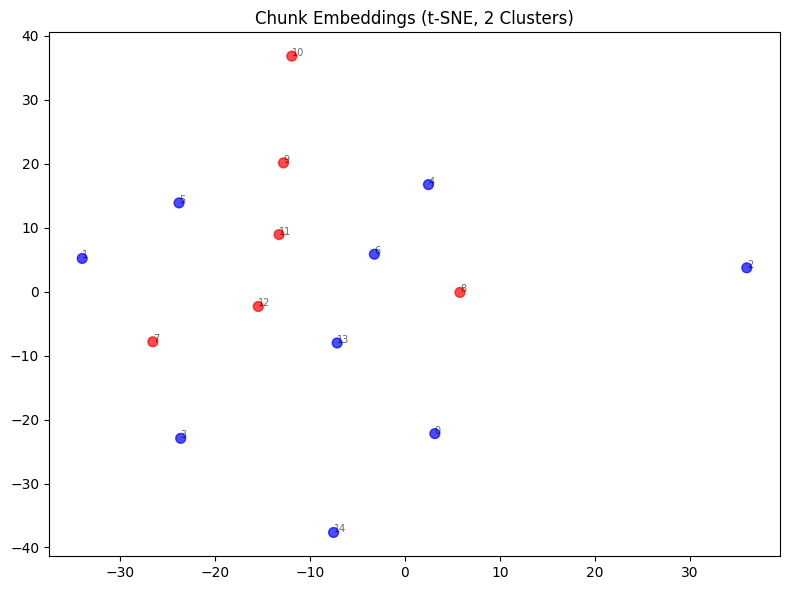

In [ ]:
# Create a map for chunks
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

# Dimensionality reduction (t-SNE)
reduced = TSNE(
    n_components=2,
    random_state=42,
    perplexity=min(30, len(embeddings) - 1)
).fit_transform(np.array(embeddings))

# Clustering (KMeans)
labels = KMeans(
    n_clusters=2,
    random_state=42
).fit_predict(np.array(embeddings))

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(
    reduced[:, 0],
    reduced[:, 1],
    c=labels,
    cmap="bwr",
    alpha=0.7,
    s=50
)

# Annotate points
for i, (x, y) in enumerate(reduced):
    plt.annotate(str(i), (x, y), fontsize=7, alpha=0.6)

plt.title("Chunk Embeddings (t-SNE, 2 Clusters)")
plt.tight_layout()
plt.show()

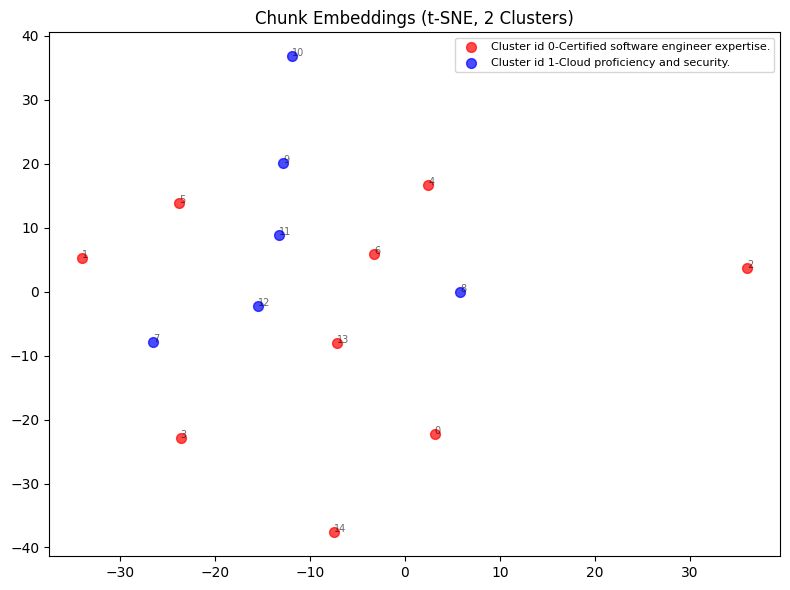

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from openai import OpenAI

reduced = TSNE(n_components=2, random_state=42, perplexity=min(30, len(embeddings)-1)).fit_transform(np.array(embeddings))

labels = KMeans(n_clusters=2, random_state=42).fit_predict(np.array(embeddings))

# Get cluster descriptions first
descriptions = {}
for cluster_id in range(2):
    cluster_chunks = [chunks[i] for i, l in enumerate(labels) if l == cluster_id]
    sample = "\n---\n".join(cluster_chunks[:5])

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        max_tokens=200,
        messages=[{"role": "user", "content": f"Summarize the theme of these text in 1 short sentence less than 5 words {sample}"}]
    )
    descriptions[cluster_id] = response.choices[0].message.content
    #print(f"Cluster {cluster_id}: {descriptions[cluster_id]}\n")
                                   

# Plot with legend
colors = ["red", "blue"]
plt.figure(figsize=(8, 6))

for cluster_id in range(2):
    mask = labels == cluster_id
    plt.scatter(reduced[mask, 0], reduced[mask, 1], c=colors[cluster_id], alpha=0.7, s=50, label=f"Cluster id {cluster_id}-{descriptions[cluster_id]}")

for i, (x, y) in enumerate(reduced):
    plt.annotate(str(i), (x, y), fontsize=7, alpha=0.6)

plt.title("Chunk Embeddings (t-SNE, 2 Clusters)")
plt.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()

In [9]:
import chromadb
chroma_client = chromadb.PersistentClient(path="./chroma_db_digital_twin")

collection = chroma_client.get_or_create_collection(name="digital_twin")

if collection.get()["ids"]:
    collection.delete(collection.get()["ids"])


#pprint(collection.get())

In [10]:
#prepate data for chroma
ids = [f"chunk_{i}" for i in range(len(chunks))]

metadatas = [{"source":"chroma_digital_twin", "chunk_index": i } for i in range(len(chunks))]

collection.add(
    ids=ids,
    embeddings=embeddings,
    documents=chunks,
    metadatas=metadatas
)

#pprint(collection.get(include=["documents"]))

In [11]:
test_query = "Can Si Lam cook?"
#test_query2="Team work and collaboration"

response = client.embeddings.create(
    model = "text-embedding-3-small",
    input = [test_query]
)

query_embedding = [response.data[0].embedding]#,response.data[1].embedding]

results = collection.query(
    query_embeddings = query_embedding,
    n_results=3,
    include = ["documents","metadatas"]
)

#pprint(results)

### Step 3: Prepare the list of tools for LLM

In [12]:
tools = []


Step 3a : Add tool calling for pushover

In [13]:
pushover_user  = os.getenv("PUSHOVER_USER")
pushover_token = os.getenv("PUSHOVER_TOKEN")
pushover_url   = "https://api.pushover.net/1/messages.json"

#Test Pushover
import requests

def send_notification(message: str):
    pay_load = {"user":pushover_user,
                "token": pushover_token,
                "message": message}
    requests.post(pushover_url, data = pay_load)
send_notification_function = {

    "name" : "send_notification",
    "description": "Send a push notification to user phone via pushover. Tell the user important task, event",
    "parameters": {
        "type": "object",
        "properties":{
            "message": {
                "type": "string",
                "description":"The notification message to send to user device"
            }
        },
        "required": ["message"]
    }
}
tools.append({"type": "function","function": send_notification_function})

### Step 3b: Add dice rolling tool 

In [14]:
import random

# simulate rolling a dice
def dice_roll():
    result = random.randint(1,6)
    return result 

roll_dice_function = {
    "name" : "dice_roll",
    "description": "Return a number by rolling a dice",
    "parameters": {
        "type": "object",
        "properties":{
            
        },
        "required": []
    }
}

tools.append( {"type": "function","function": roll_dice_function})

### Step 4: Function to handle tool calling

In [15]:
def handle_tool_call(tool_calls):
    tools_results = []
    # return what to add to our context (about tool call results, a dictionary)
    for tool_call in tool_calls:
        function_name = tool_call.function.name
        #print(f"Calling function {function_name}")
        args = json.loads(tool_call.function.arguments)

        #Route to function name
        if function_name == "send_notification":

            send_notification(args['message'])
            #print(f"Send notification: {args['message']}")
            content = f"Notitication sent: {args['message']}"
        elif function_name == "dice_roll":

            #print(f"Send notification: {args['message']}")
            content = f"Rolled: {dice_roll()}"
        else:
            content = f"Unknown function {function_name}"

        tool_call_result  = {
            "role":"tool",
            "content":content,
            "tool_call_id":tool_call.id
            
        }

        tools_results.append(tool_call_result)

    return tools_results

### Step 4: Function to Process conversation turn

In [ ]:
def response_ai(message, history):
    

    response = client.embeddings.create(
        model = "text-embedding-3-small",
        input = [message]
    )

    query_embedding = response.data[0].embedding

    results = collection.query(
        query_embeddings = query_embedding,
        n_results=3,
        include = ["documents"]
    )

    #pprint(results)
    system_message_enhanced = system_message + "\n\nContent:\n" + "\n---\n".join(results["documents"][0])
    messages = [{"role":"system", "content": system_message_enhanced}] \
               + history \
               + [{"role":"user", "content": message}] 

    
    response = client.chat.completions.create(
        model = "gpt-4.1-mini",
        messages= messages,
        tools=tools,
        tool_choice="auto"
    )

    message = response.choices[0].message
    loop = 0
    tool_count = len(message.tool_calls) if message is not None and message.tool_calls is not None else 0

    pprint(f"Tools count: {tool_count}")
    while message.tool_calls:
        loop += 1
        if (loop > tool_count): break
        
        #handle tool call
        tool_result = handle_tool_call(message.tool_calls) #whole list of tools

        #add message to context
        messages.append(message)

        #add info about tool call response to context, i.e. mesages
        messages.extend(tool_result)

        #invokde LLM one more time to get its updated response
        response = client.chat.completions.create(
            model='gpt-4.1-mini',
            messages=messages,
            tools=tools #will be in the future
        )
        message = response.choices[0].message
        
    return(message.content)


### Step 6: Call Gradio

In [17]:
gr.ChatInterface(fn=response_ai, autofocus=True, autoscroll=True, submit_btn=True, examples=["hello", "hola", "merhaba"], title="Echo Bot").launch(inbrowser=True) #, share=True)

* Running on local URL:  http://127.0.0.1:7871
* To create a public link, set `share=True` in `launch()`.


'Tools count: 0'
'Tools count: 0'
